In [1]:
import os
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
    precision_recall_curve, average_precision_score
)

import matplotlib.pyplot as plt

# ---- paths ----
TEXT_PROC_PATH = "../data_fakenewsnet/processed/politifact_text_processed.csv"
REAL_PATH = "../data_fakenewsnet/raw/politifact/politifact_real.csv"
FAKE_PATH = "../data_fakenewsnet/raw/politifact/politifact_fake.csv"

OUT_DIR = "../outputs/fakenewsnet_hybrid"
os.makedirs(OUT_DIR, exist_ok=True)


In [2]:
# Load text dataset (already cleaned in Step 1)
text_df = pd.read_csv(TEXT_PROC_PATH)
print("Text processed shape:", text_df.shape)
print(text_df["label"].value_counts())

# Load raw politifact csvs (contain tweet_ids / title / url etc.)
real_df = pd.read_csv(REAL_PATH)
fake_df = pd.read_csv(FAKE_PATH)
real_df["label"] = 0
fake_df["label"] = 1
meta_df = pd.concat([real_df, fake_df], ignore_index=True)

print("Meta shape:", meta_df.shape)
print("Meta columns:", meta_df.columns.tolist())
print(meta_df["label"].value_counts())


Text processed shape: (1053, 2)
label
0    622
1    431
Name: count, dtype: int64
Meta shape: (1056, 5)
Meta columns: ['id', 'news_url', 'title', 'tweet_ids', 'label']
label
0    624
1    432
Name: count, dtype: int64


In [4]:
def parse_tweet_ids(x):
    """Tweet ids are often stored like 'id1\\tid2\\tid3'. Return list length safely."""
    if pd.isna(x):
        return 0
    s = str(x).strip()
    if not s:
        return 0
    # common delimiter in this dataset: \t
    parts = [p for p in s.split("\t") if p.strip()]
    return len(parts)

# tweet_count from tweet_ids if exists
if "tweet_ids" in meta_df.columns:
    meta_df["tweet_count"] = meta_df["tweet_ids"].apply(parse_tweet_ids)
else:
    meta_df["tweet_count"] = 0

meta_df["has_tweets"] = (meta_df["tweet_count"] > 0).astype(int)

# optional title length
if "title" in meta_df.columns:
    meta_df["title_len"] = meta_df["title"].astype(str).str.len()
else:
    meta_df["title_len"] = 0

# optional url domain
if "news_url" in meta_df.columns:
    meta_df["url_len"] = meta_df["news_url"].astype(str).str.len()
else:
    meta_df["url_len"] = 0

meta_features = ["tweet_count", "has_tweets", "title_len", "url_len"]
meta_df[meta_features + ["label"]].describe(include="all")


,tweet_count,has_tweets,title_len,url_len,label
count,1056.000000,1056.000000,1056.000000,1056.000000,1056.000000
mean,552.571970,0.758523,59.889205,87.780303,0.409091
std,2126.317823,0.428182,31.335519,39.630533,0.491899
min,0.000000,0.000000,10.000000,3.000000,0.000000
25%,1.000000,1.000000,38.000000,61.000000,0.000000
50%,30.000000,1.000000,59.000000,91.000000,0.000000
75%,246.250000,1.000000,78.000000,113.250000,1.000000
max,29060.000000,1.000000,340.000000,258.000000,1.000000


In [5]:
# Align by row order (valid because Step 1 built df by concat real then fake)
# Safety check: labels should match row-by-row
min_len = min(len(text_df), len(meta_df))
aligned = pd.concat(
    [
        text_df.iloc[:min_len].reset_index(drop=True),
        meta_df[meta_features].iloc[:min_len].reset_index(drop=True)
    ],
    axis=1
)

print("Aligned shape:", aligned.shape)

# label consistency check
label_match_rate = (aligned["label"].values == meta_df["label"].iloc[:min_len].values).mean()
print("Label match rate vs meta_df:", label_match_rate)

aligned.head()


Aligned shape: (1053, 6)
Label match rate vs meta_df: 0.9981006647673314


,clean_text,label,tweet_count,has_tweets,title_len,url_len
0,national federation of independent business,0,1174,1,43,25
1,comments in fayetteville nc,0,51,1,27,52
2,romney makes pitch hoping to close deal electi...,0,0,0,78,145
3,democratic leaders say house democrats are uni...,0,0,0,73,142
4,budget of the united states government fy,0,8,1,47,99


In [6]:
from scipy.sparse import hstack, csr_matrix

# ---------------------------
# Split X/y
# ---------------------------
y = aligned["label"].astype(int)

X_text = aligned["clean_text"].astype(str)

meta_feature_cols = ["tweet_count", "has_tweets", "title_len", "url_len"]
X_meta = aligned[meta_feature_cols].fillna(0)

X_text_train, X_text_test, X_meta_train, X_meta_test, y_train, y_test = train_test_split(
    X_text, X_meta, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------
# TF-IDF on text
# ---------------------------
tfidf = TfidfVectorizer(stop_words="english", max_features=50000, ngram_range=(1, 2))
X_tfidf_train = tfidf.fit_transform(X_text_train)
X_tfidf_test  = tfidf.transform(X_text_test)

# ---------------------------
# Scale numeric features
# ---------------------------
scaler = StandardScaler()
X_meta_train_scaled = scaler.fit_transform(X_meta_train)
X_meta_test_scaled  = scaler.transform(X_meta_test)

# convert dense -> sparse so we can hstack with TF-IDF
X_meta_train_sparse = csr_matrix(X_meta_train_scaled)
X_meta_test_sparse  = csr_matrix(X_meta_test_scaled)

# ---------------------------
# Combine (Hybrid)
# ---------------------------
X_train = hstack([X_tfidf_train, X_meta_train_sparse])
X_test  = hstack([X_tfidf_test,  X_meta_test_sparse])

clf = LogisticRegression(max_iter=2000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8293838862559242
              precision    recall  f1-score   support

           0      0.840     0.880     0.859       125
           1      0.812     0.756     0.783        86

    accuracy                          0.829       211
   macro avg      0.826     0.818     0.821       211
weighted avg      0.829     0.829     0.828       211

Confusion matrix:
 [[110  15]
 [ 21  65]]


In [7]:
y_proba = clf.predict_proba(X_test)[:, 1]

def eval_threshold(thresh: float):
    y_pred_t = (y_proba >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    return {
        "threshold": thresh,
        "accuracy": accuracy_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0),
        "TP": tp, "FP": fp, "TN": tn, "FN": fn
    }

thresholds = np.round(np.arange(0.1, 1.0, 0.1), 1)
results = pd.DataFrame([eval_threshold(t) for t in thresholds])

os.makedirs(OUT_DIR, exist_ok=True)
results_path = os.path.join(OUT_DIR, "threshold_results.csv")
results.to_csv(results_path, index=False)

results


,threshold,accuracy,precision,recall,f1,TP,FP,TN,FN
0,0.1,0.601896,0.505952,0.988372,0.669291,85,83,42,1
1,0.2,0.701422,0.581560,0.953488,0.722467,82,59,66,4
2,0.3,0.763033,0.647541,0.918605,0.759615,79,43,82,7
3,0.4,0.815166,0.752688,0.813953,0.782123,70,23,102,16
4,0.5,0.829384,0.812500,0.755814,0.783133,65,15,110,21
5,0.6,0.791469,0.903846,0.546512,0.681159,47,5,120,39
6,0.7,0.748815,0.945946,0.406977,0.569106,35,2,123,51
7,0.8,0.663507,0.941176,0.186047,0.310680,16,1,124,70
8,0.9,0.611374,1.000000,0.046512,0.088889,4,0,125,82


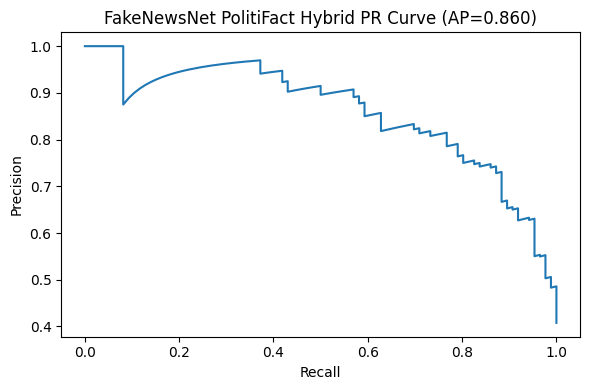

Average Precision (AP): 0.859833410465665
Saved: ../outputs/fakenewsnet_hybrid/threshold_results.csv
Saved: ../outputs/fakenewsnet_hybrid/pr_curve.png


In [8]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"FakeNewsNet PolitiFact Hybrid PR Curve (AP={ap:.3f})")
plt.tight_layout()

pr_path = os.path.join(OUT_DIR, "pr_curve.png")
plt.savefig(pr_path, dpi=200)
plt.show()

print("Average Precision (AP):", ap)
print("Saved:", results_path)
print("Saved:", pr_path)


In [9]:
PROC_HYBRID_PATH = "../data_fakenewsnet/processed/politifact_hybrid_features.csv"
os.makedirs("../data_fakenewsnet/processed", exist_ok=True)

save_cols = ["clean_text", "label"] + meta_feature_cols
aligned[save_cols].to_csv(PROC_HYBRID_PATH, index=False)

print("Saved:", PROC_HYBRID_PATH)


Saved: ../data_fakenewsnet/processed/politifact_hybrid_features.csv


Conclusion:

This notebook trains a hybrid misinformation classifier on the FakeNewsNet PolitiFact subset by combining TF-IDF text features with platform style metadata features derived from social context (e.g., tweet engagement indicators and simple URL/title statistics). Performance is evaluated with a classification report, threshold table, and precision–recall curve.

Compared to the text only baseline, the hybrid setup tests whether diffusion related signals add predictive value beyond language alone. This stage sets up the final comparison across (1) text-only, (2) metadata-only, and (3) hybrid models using a dataset where text and metadata are available for the same news items.